In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from collections import Counter
import seaborn as sns

IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [37]:
# Chargement CIFAR-100 en mode fine (100 classes)
(x_train_fine, y_train_fine), (x_test_fine, y_test_fine) = cifar100.load_data(label_mode='fine')

# Chargement CIFAR-100 en mode coarse (20 super-classes)
(x_train_coarse, y_train_coarse), (x_test_coarse, y_test_coarse) = cifar100.load_data(label_mode='coarse')

# Vérification de cohérence entre les deux chargements (mêmes images, labels différents)
assert np.array_equal(x_train_fine, x_train_coarse), "Les images train diffèrent entre fine et coarse"
assert np.array_equal(x_test_fine, x_test_coarse), "Les images test diffèrent entre fine et coarse"

# On garde une seule variable image
x_train, x_test = x_train_fine, x_test_fine

# Noms des classes fine (100)
fine_labels = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can',
    'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach',
    'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish',
    'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower',
    'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit',
    'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk',
    'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower',
    'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train',
    'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
 ]

# Noms des super-classes coarse (20)
coarse_labels = [
    'aquatic_mammals', 'fish', 'flowers', 'food_containers', 'fruit_and_vegetables',
    'household_electrical_devices', 'household_furniture', 'insects', 'large_carnivores',
    'large_man-made_outdoor_things', 'large_natural_outdoor_scenes',
    'large_omnivores_and_herbivores', 'medium_mammals', 'non-insect_invertebrates',
    'people', 'reptiles', 'small_mammals', 'trees', 'vehicles_1', 'vehicles_2'
 ]

print("=== 1) Dimensions ===")
print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")
print(f"Dimension d'une image: {x_train.shape[1:]}")
print()

print("=== 2) Nombre d'images par classe ===")
fine_train_counts = np.bincount(y_train_fine.flatten(), minlength=100)
fine_test_counts = np.bincount(y_test_fine.flatten(), minlength=100)
fine_total_counts = fine_train_counts + fine_test_counts

print(f"Classes fine uniques (train): {len(np.unique(y_train_fine))}/100")
print(f"Classes coarse uniques (train): {len(np.unique(y_train_coarse))}/20")
print(f"Images/classe fine (train): min={fine_train_counts.min()}, max={fine_train_counts.max()}")
print(f"Images/classe fine (test): min={fine_test_counts.min()}, max={fine_test_counts.max()}")
print(f"Images/classe fine (total): min={fine_total_counts.min()}, max={fine_total_counts.max()}")
print("(Attendu: train=500, test=100, total=600 par classe fine)")
print()

print("=== 3) Range des valeurs de pixels ===")
print(f"dtype: {x_train.dtype}")
print(f"Train  min/max: {x_train.min()} / {x_train.max()}")
print(f"Test   min/max: {x_test.min()} / {x_test.max()}")
print("(Attendu pour CIFAR-100 brut: 0 à 255)")
print()

print("=== 4) Labels fine et coarse chargés ===")
print(f"Nombre de labels fine: {len(fine_labels)}")
print(f"Nombre de labels coarse: {len(coarse_labels)}")
print("Exemples fine (id -> nom):")
for i in [0, 1, 10, 50, 99]:
    print(f"  {i:2d} -> {fine_labels[i]}")
print("Exemples coarse (id -> nom):")
for i in [0, 1, 5, 10, 19]:
    print(f"  {i:2d} -> {coarse_labels[i]}")

=== 1) Dimensions ===
x_train: (50000, 32, 32, 3), x_test: (10000, 32, 32, 3)
Dimension d'une image: (32, 32, 3)

=== 2) Nombre d'images par classe ===
Classes fine uniques (train): 100/100
Classes coarse uniques (train): 20/20
Images/classe fine (train): min=500, max=500
Images/classe fine (test): min=100, max=100
Images/classe fine (total): min=600, max=600
(Attendu: train=500, test=100, total=600 par classe fine)

=== 3) Range des valeurs de pixels ===
dtype: uint8
Train  min/max: 0 / 255
Test   min/max: 0 / 255
(Attendu pour CIFAR-100 brut: 0 à 255)

=== 4) Labels fine et coarse chargés ===
Nombre de labels fine: 100
Nombre de labels coarse: 20
Exemples fine (id -> nom):
   0 -> apple
   1 -> aquarium_fish
  10 -> bowl
  50 -> mouse
  99 -> worm
Exemples coarse (id -> nom):
   0 -> aquatic_mammals
   1 -> fish
   5 -> household_electrical_devices
  10 -> large_natural_outdoor_scenes
  19 -> vehicles_2


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_25576\1592045703.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.985])


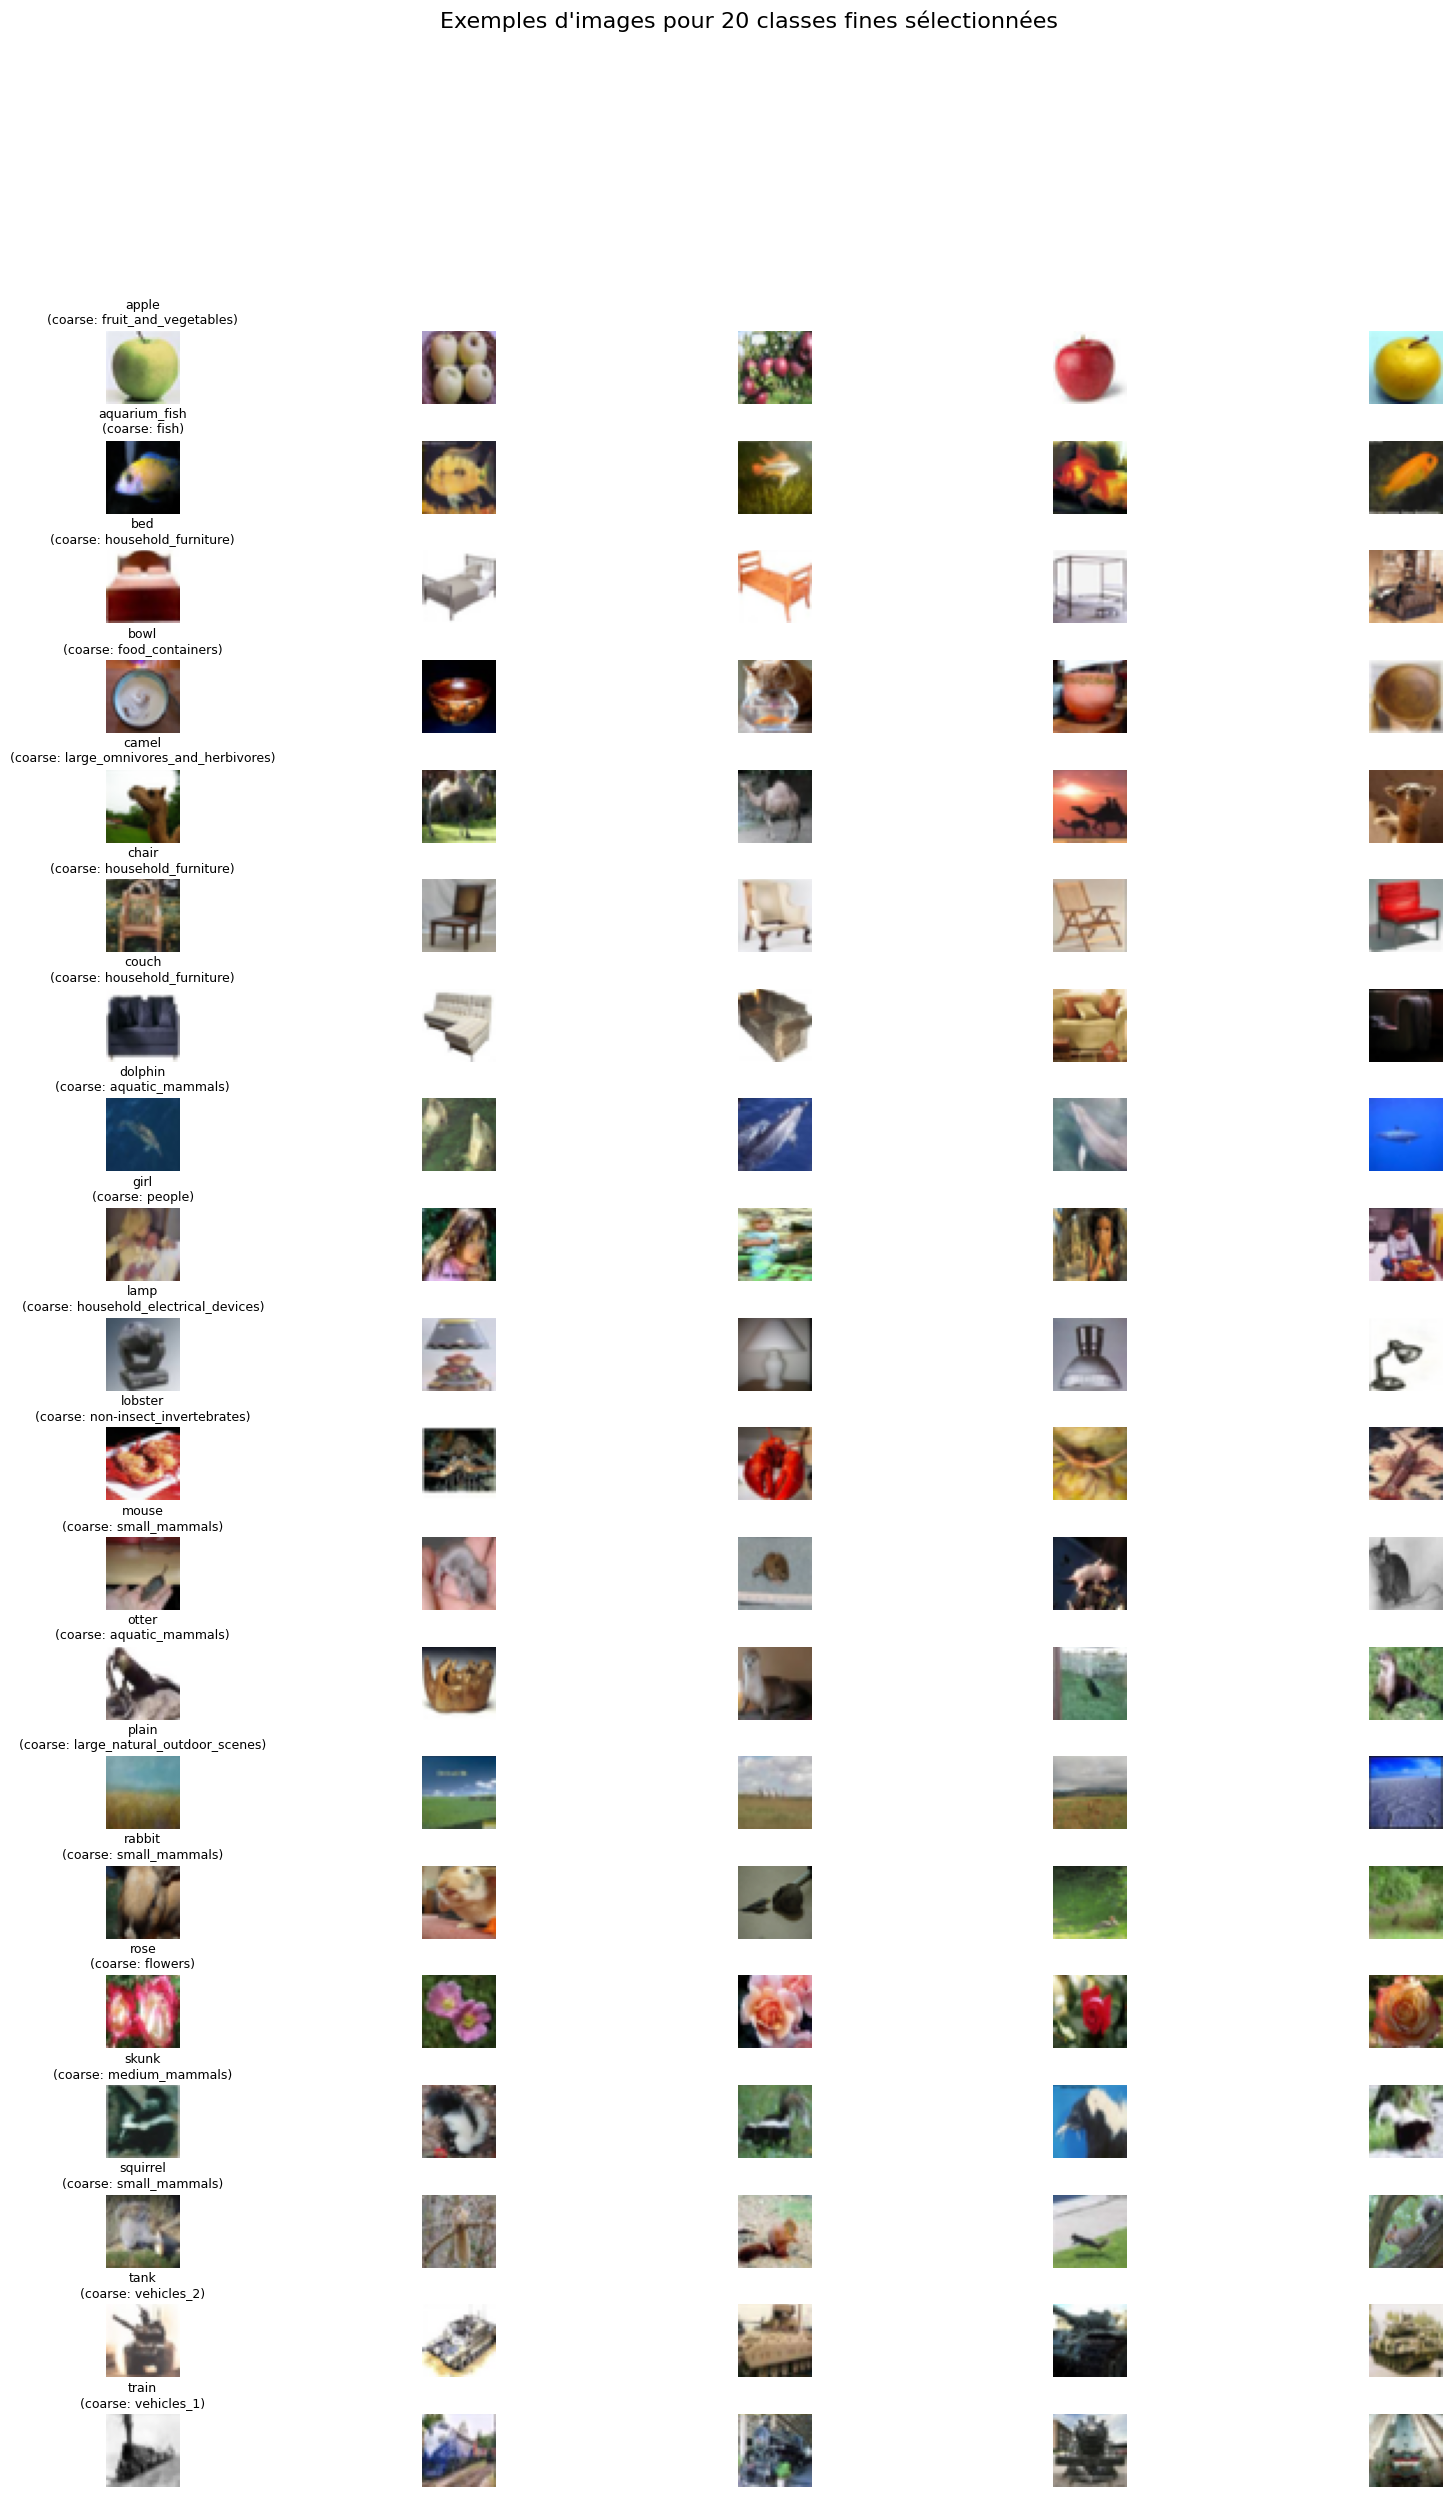

In [38]:
selected_classes = [0, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90]
num_images_per_class = 5

assert len(x_train) == len(y_train_fine) == len(y_train_coarse), "Les tailles ne correspondent pas"

y_fine = y_train_fine.flatten()
y_coarse = y_train_coarse.flatten()

rng = np.random.default_rng(42)

fig = plt.figure(figsize=(20, 28))
gs = gridspec.GridSpec(len(selected_classes), num_images_per_class, wspace=0.1, hspace=0.5)

for i, class_id in enumerate(selected_classes):
    class_indices = np.where(y_fine == class_id)[0]

    if len(class_indices) == 0:
        continue

    n_select = min(num_images_per_class, len(class_indices))
    chosen_indices = rng.choice(class_indices, size=n_select, replace=False)

    coarse_id = y_coarse[class_indices[0]]
    fine_name = fine_labels[class_id]
    coarse_name = coarse_labels[coarse_id]

    for j in range(num_images_per_class):
        ax = fig.add_subplot(gs[i, j])
        ax.axis("off")

        if j < n_select:
            idx = chosen_indices[j]
            ax.imshow(x_train[idx])

            if j == 0:
                ax.set_title(f"{fine_name}\n(coarse: {coarse_name})", fontsize=9)

fig.suptitle("Exemples d'images pour 20 classes fines sélectionnées", fontsize=16, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

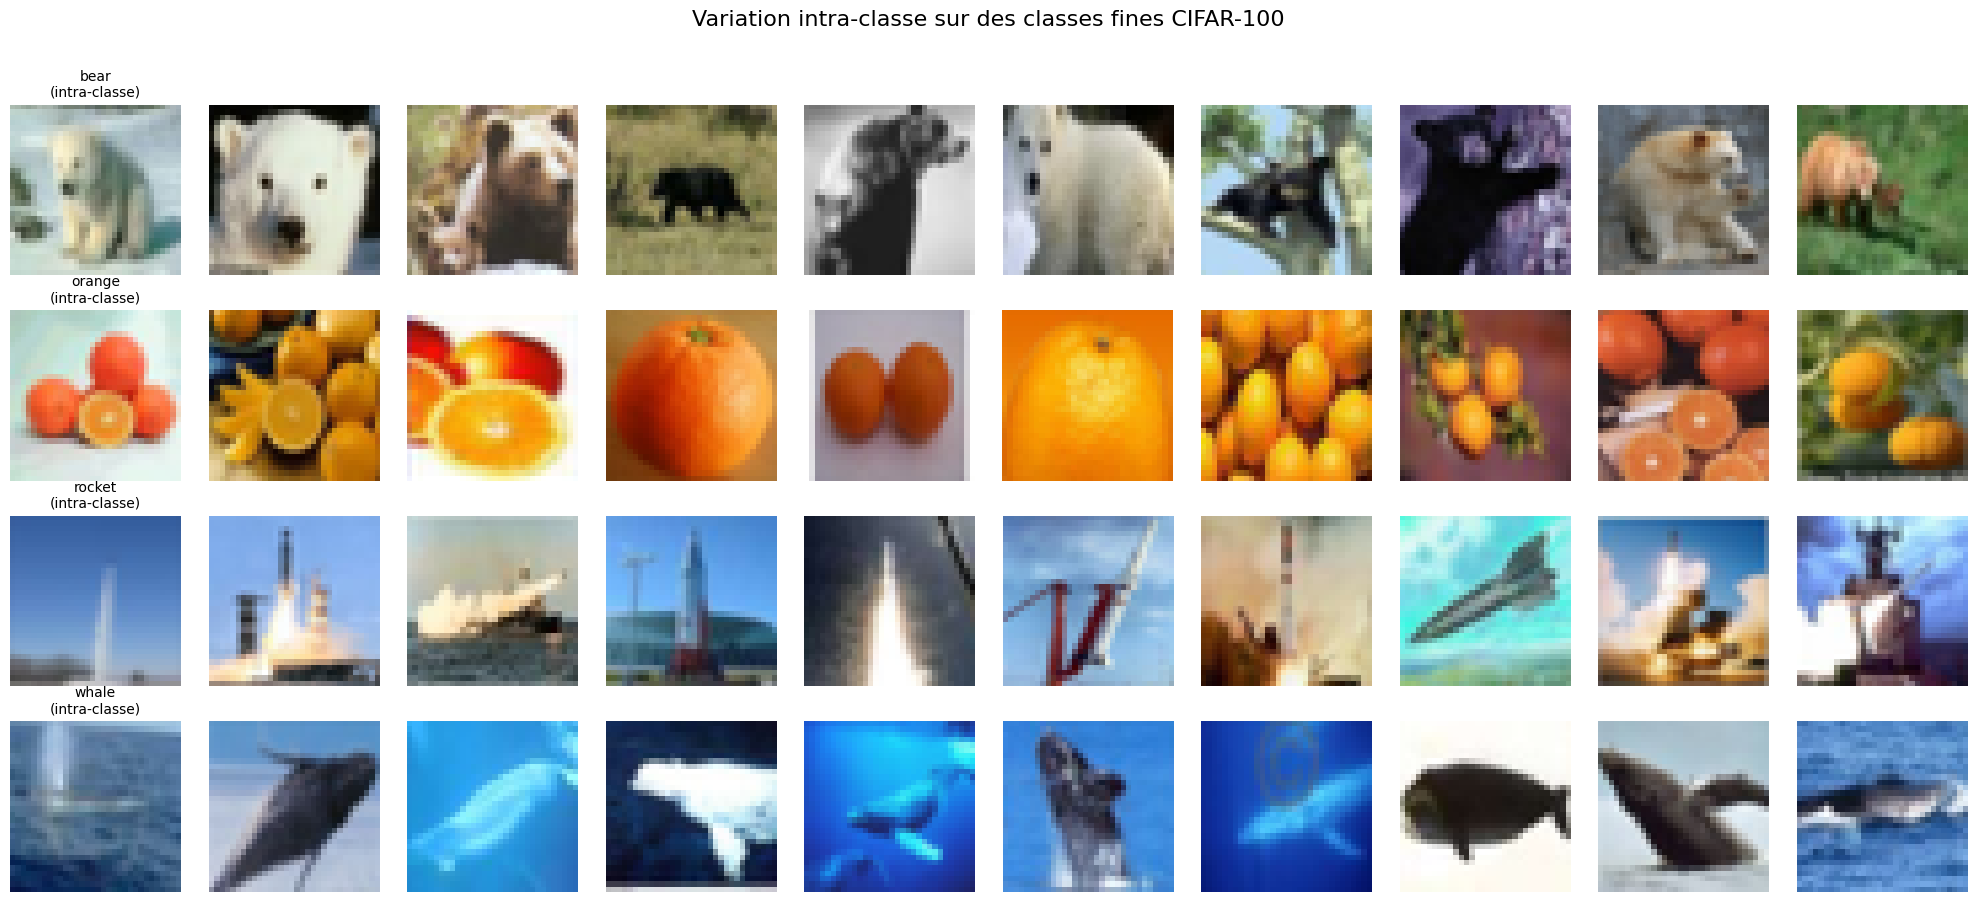

In [39]:
# Variation intra-classe : visualiser des exemples multiples d'une même classe fine
classes_intra = [3, 53, 69, 95]  
samples_per_class = 10

y_fine = y_train_fine.flatten()
rng = np.random.default_rng(123)

fig, axes = plt.subplots(len(classes_intra), samples_per_class, figsize=(2.0 * samples_per_class, 2.2 * len(classes_intra)))

for row, class_id in enumerate(classes_intra):
    class_indices = np.where(y_fine == class_id)[0]
    chosen = rng.choice(class_indices, size=samples_per_class, replace=False)

    for col, idx in enumerate(chosen):
        ax = axes[row, col]
        ax.imshow(x_train[idx])
        ax.axis('off')
        if col == 0:
            ax.set_title(f"{fine_labels[class_id]}\n(intra-classe)", fontsize=10)

fig.suptitle("Variation intra-classe sur des classes fines CIFAR-100", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [40]:
# Statistique de l'image 
print("=== Statistiques globales sur les images ===")
print(f"Nombre total d'images: {len(x_train) + len(x_test)}")
print(f"Nombre d'images par classe fine (train): {Counter(y_train_fine.flatten())}")
print(f"Nombre d'images par classe fine (test): {Counter(y_test_fine.flatten())}")
print(f"Nombre d'images par classe coarse (train): {Counter(y_train_coarse.flatten())}")
print(f"Nombre d'images par classe coarse (test): {Counter(y_test_coarse.flatten())}")


=== Statistiques globales sur les images ===
Nombre total d'images: 60000
Nombre d'images par classe fine (train): Counter({np.int64(19): 500, np.int64(29): 500, np.int64(0): 500, np.int64(11): 500, np.int64(1): 500, np.int64(86): 500, np.int64(90): 500, np.int64(28): 500, np.int64(23): 500, np.int64(31): 500, np.int64(39): 500, np.int64(96): 500, np.int64(82): 500, np.int64(17): 500, np.int64(71): 500, np.int64(8): 500, np.int64(97): 500, np.int64(80): 500, np.int64(74): 500, np.int64(59): 500, np.int64(70): 500, np.int64(87): 500, np.int64(84): 500, np.int64(64): 500, np.int64(52): 500, np.int64(42): 500, np.int64(47): 500, np.int64(65): 500, np.int64(21): 500, np.int64(22): 500, np.int64(81): 500, np.int64(24): 500, np.int64(78): 500, np.int64(45): 500, np.int64(49): 500, np.int64(56): 500, np.int64(76): 500, np.int64(89): 500, np.int64(73): 500, np.int64(14): 500, np.int64(9): 500, np.int64(6): 500, np.int64(20): 500, np.int64(98): 500, np.int64(36): 500, np.int64(55): 500, np.int6

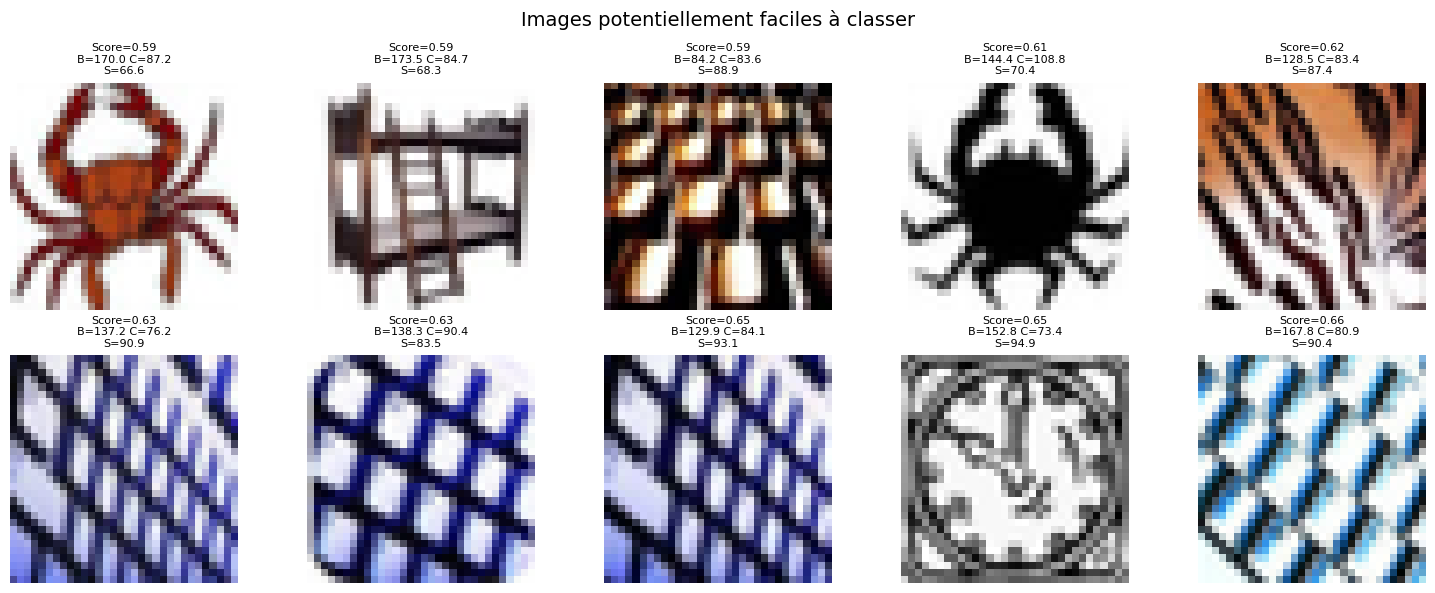

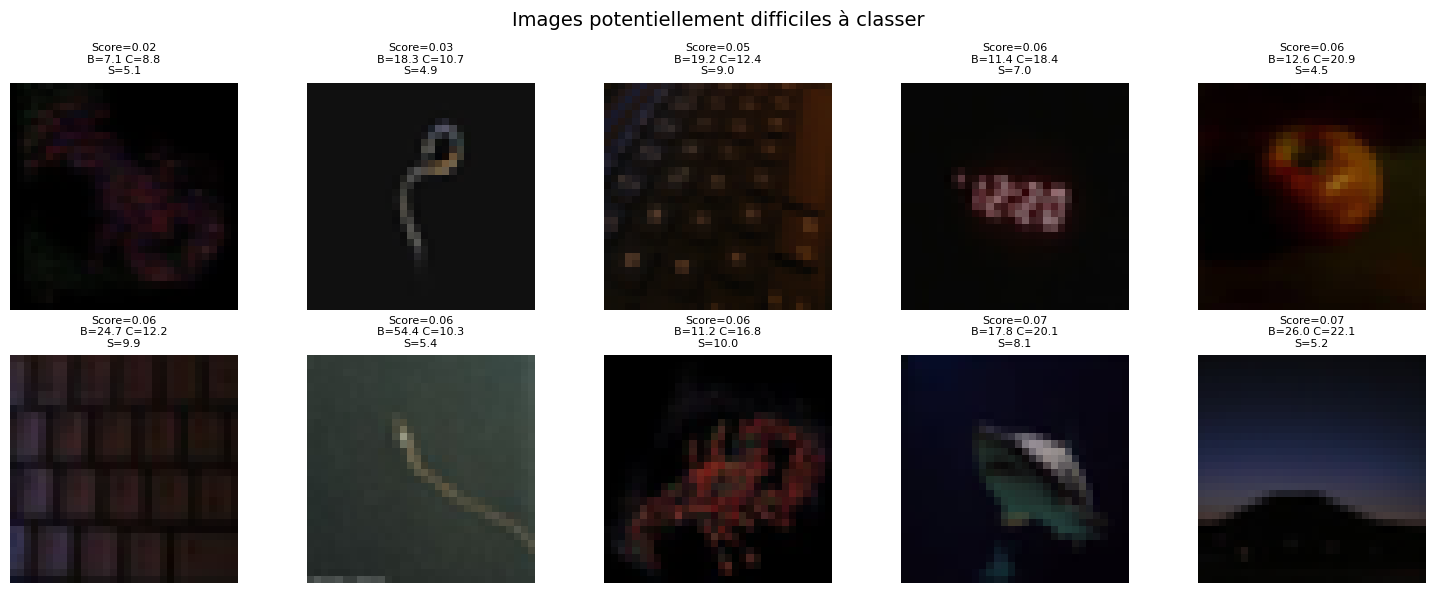

In [41]:
def compute_brightness(img):
    # luminosité moyenne
    return img.mean()

def compute_contrast(img):
    # écart-type des pixels
    return img.std()

def compute_sharpness(img):
    # approximation simple de netteté via différences entre pixels voisins
    img_gray = img.mean(axis=2) if img.ndim == 3 else img
    dx = np.abs(np.diff(img_gray, axis=1)).mean()
    dy = np.abs(np.diff(img_gray, axis=0)).mean()
    return dx + dy

def compute_complexity(img):
    # complexité visuelle = variation globale
    img_gray = img.mean(axis=2) if img.ndim == 3 else img
    return np.var(img_gray)

brightness_scores = np.array([compute_brightness(img) for img in x_train])
contrast_scores   = np.array([compute_contrast(img) for img in x_train])
sharpness_scores  = np.array([compute_sharpness(img) for img in x_train])
complexity_scores = np.array([compute_complexity(img) for img in x_train])


def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

brightness_n = normalize(brightness_scores)
contrast_n   = normalize(contrast_scores)
sharpness_n  = normalize(sharpness_scores)
complexity_n = normalize(complexity_scores)

# score "facilité" simple
ease_score = (
    0.35 * contrast_n +
    0.35 * sharpness_n +
    0.20 * brightness_n -
    0.10 * complexity_n
)


n_show = 10

easy_idx = np.argsort(ease_score)[-n_show:]      
hard_idx = np.argsort(ease_score)[:n_show]       


def plot_selected_images(indices, title):
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_train[idx])
        plt.axis("off")
        plt.title(
            f"Score={ease_score[idx]:.2f}\n"
            f"B={brightness_scores[idx]:.1f} "
            f"C={contrast_scores[idx]:.1f}\n"
            f"S={sharpness_scores[idx]:.1f}",
            fontsize=8
        )
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_selected_images(easy_idx, "Images potentiellement faciles à classer")
plot_selected_images(hard_idx, "Images potentiellement difficiles à classer")

Top 10 paires de classes les plus similaires (distance L2 sur image moyenne) :
  squirrel             <-> spider                (dist=284.7)
  raccoon              <-> porcupine             (dist=316.4)
  lizard               <-> kangaroo              (dist=318.7)
  beaver               <-> bear                  (dist=330.0)
  crocodile            <-> raccoon               (dist=331.4)
  lizard               <-> snake                 (dist=331.9)
  leopard              <-> crocodile             (dist=338.7)
  snail                <-> squirrel              (dist=342.9)
  snake                <-> squirrel              (dist=350.5)
  tiger                <-> leopard               (dist=352.3)


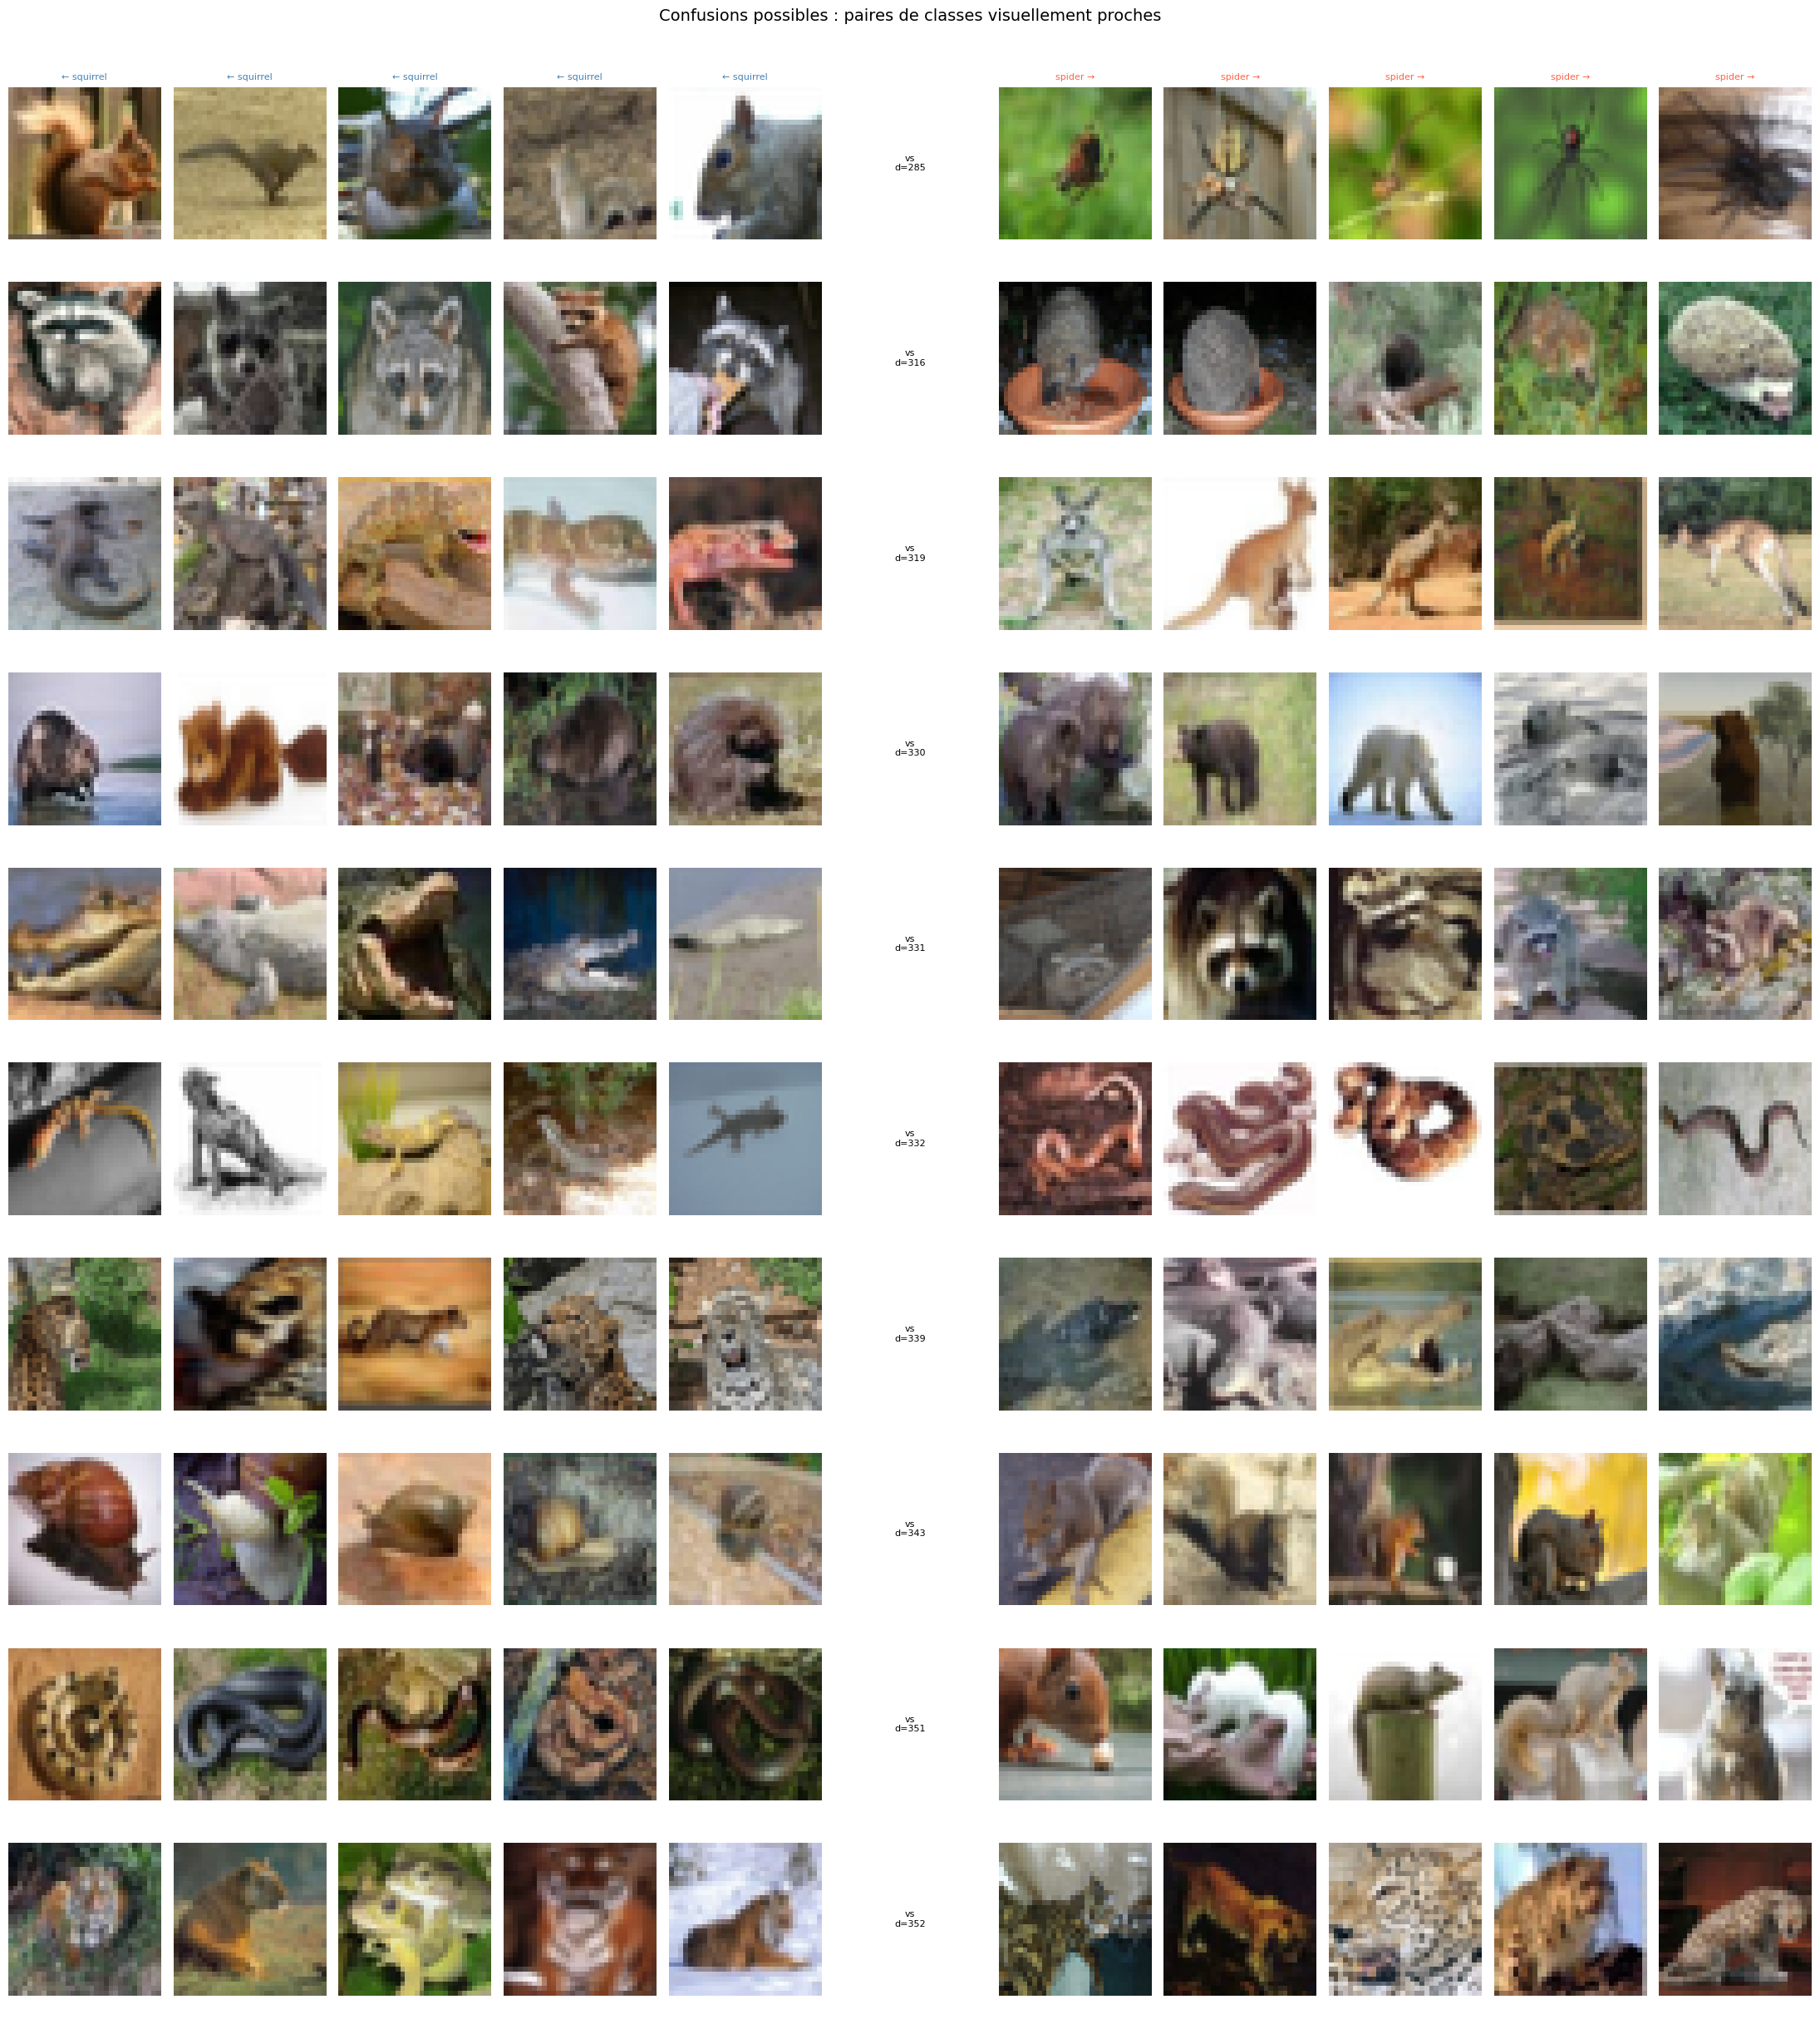

In [42]:
# Identifier les confusions possibles : paires de classes visuellement proches
# Stratégie : comparer les moyennes des images par classe (distance L2 dans l'espace des pixels)

y_fine_flat = y_train_fine.flatten()

# Calcul de l'image moyenne par classe
class_means = np.zeros((100, 32 * 32 * 3), dtype=np.float32)
for c in range(100):
    idx = np.where(y_fine_flat == c)[0]
    class_means[c] = x_train[idx].reshape(len(idx), -1).mean(axis=0)

# Calcul de la matrice de distances L2 entre classes
from scipy.spatial.distance import cdist
dist_matrix = cdist(class_means, class_means, metric='euclidean')
np.fill_diagonal(dist_matrix, np.inf)  # ignorer la diagonale

# Top 10 paires les plus proches
n_pairs = 10
flat_idx = np.argsort(dist_matrix.ravel())[:n_pairs * 2]
shown = set()
pairs = []
for fi in flat_idx:
    i, j = divmod(fi, 100)
    key = tuple(sorted((i, j)))
    if key not in shown:
        shown.add(key)
        pairs.append((i, j, dist_matrix[i, j]))
    if len(pairs) == n_pairs:
        break

print("Top 10 paires de classes les plus similaires (distance L2 sur image moyenne) :")
for i, j, d in pairs:
    print(f"  {fine_labels[i]:20s} <-> {fine_labels[j]:20s}  (dist={d:.1f})")

# Visualisation : 5 exemples côte à côte pour chaque paire confusable
n_show = 5
rng = np.random.default_rng(0)

fig, axes = plt.subplots(len(pairs), n_show * 2 + 1,
                         figsize=(2.0 * (n_show * 2 + 1), 2.4 * len(pairs)))

for row, (ci, cj, d) in enumerate(pairs):
    idx_i = np.where(y_fine_flat == ci)[0]
    idx_j = np.where(y_fine_flat == cj)[0]
    chosen_i = rng.choice(idx_i, n_show, replace=False)
    chosen_j = rng.choice(idx_j, n_show, replace=False)

    for col in range(n_show * 2 + 1):
        ax = axes[row, col]
        ax.axis('off')
        if col < n_show:
            ax.imshow(x_train[chosen_i[col]])
            if row == 0:
                ax.set_title(f"← {fine_labels[ci]}", fontsize=8, color='steelblue')
        elif col == n_show:
            ax.text(0.5, 0.5, f"vs\nd={d:.0f}", ha='center', va='center',
                    fontsize=8, transform=ax.transAxes)
        else:
            ax.imshow(x_train[chosen_j[col - n_show - 1]])
            if row == 0:
                ax.set_title(f"{fine_labels[cj]} →", fontsize=8, color='tomato')

fig.suptitle("Confusions possibles : paires de classes visuellement proches", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Super-classe (coarse)               Classes fines
------------------------------------------------------------------------------------------
aquatic_mammals                     beaver, dolphin, otter, seal, whale
fish                                aquarium_fish, flatfish, ray, shark, trout
flowers                             orchid, poppy, rose, sunflower, tulip
food_containers                     bottle, bowl, can, cup, plate
fruit_and_vegetables                apple, mushroom, orange, pear, sweet_pepper
household_electrical_devices        clock, keyboard, lamp, telephone, television
household_furniture                 bed, chair, couch, table, wardrobe
insects                             bee, beetle, butterfly, caterpillar, cockroach
large_carnivores                    bear, leopard, lion, tiger, wolf
large_man-made_outdoor_things       bridge, castle, house, road, skyscraper
large_natural_outdoor_scenes        cloud, forest, mountain, plain, sea
large_omnivores_and_herbivores      

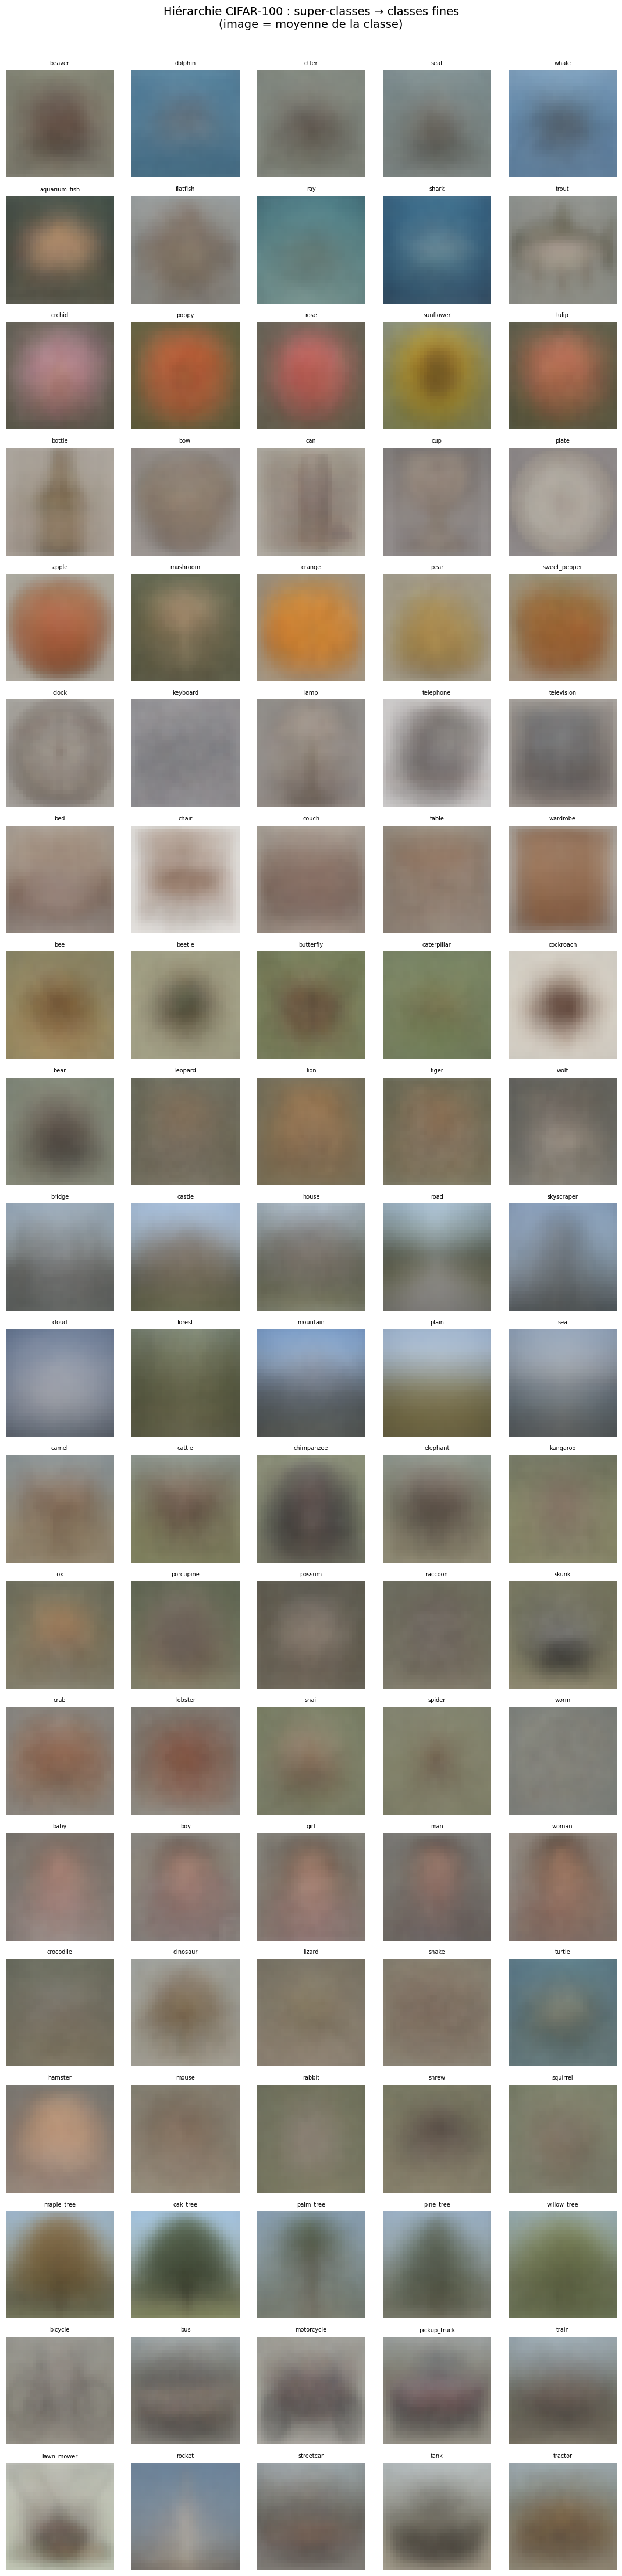

In [43]:
# Visualiser la hiérarchie super-classes (coarse) → classes fines
# Mapping officiel CIFAR-100 : coarse_id -> liste de fine_ids

coarse_to_fine = {
    0:  [4, 30, 55, 72, 95],           # aquatic_mammals
    1:  [1, 32, 67, 73, 91],           # fish
    2:  [54, 62, 70, 82, 92],          # flowers
    3:  [9, 10, 16, 28, 61],           # food_containers
    4:  [0, 51, 53, 57, 83],           # fruit_and_vegetables
    5:  [22, 39, 40, 86, 87],          # household_electrical_devices
    6:  [5, 20, 25, 84, 94],           # household_furniture
    7:  [6, 7, 14, 18, 24],            # insects
    8:  [3, 42, 43, 88, 97],           # large_carnivores
    9:  [12, 17, 37, 68, 76],          # large_man-made_outdoor_things
    10: [23, 33, 49, 60, 71],          # large_natural_outdoor_scenes
    11: [15, 19, 21, 31, 38],          # large_omnivores_and_herbivores
    12: [34, 63, 64, 66, 75],          # medium_mammals
    13: [26, 45, 77, 79, 99],          # non-insect_invertebrates
    14: [2, 11, 35, 46, 98],           # people
    15: [27, 29, 44, 78, 93],          # reptiles
    16: [36, 50, 65, 74, 80],          # small_mammals
    17: [47, 52, 56, 59, 96],          # trees
    18: [8, 13, 48, 58, 90],           # vehicles_1
    19: [41, 69, 81, 85, 89],          # vehicles_2
}

# --- Tableau texte ---
print(f"{'Super-classe (coarse)':<35} {'Classes fines'}")
print("-" * 90)
for coarse_id, fine_ids in coarse_to_fine.items():
    fine_names = ", ".join(fine_labels[f] for f in fine_ids)
    print(f"{coarse_labels[coarse_id]:<35} {fine_names}")

# --- Visualisation : image moyenne de chaque classe fine, groupée par super-classe ---
y_fine_flat = y_train_fine.flatten()
n_fine_per_coarse = 5
n_coarse = 20

fig, axes = plt.subplots(n_coarse, n_fine_per_coarse,
                         figsize=(n_fine_per_coarse * 2.2, n_coarse * 2.2))

for row, (coarse_id, fine_ids) in enumerate(coarse_to_fine.items()):
    for col, fine_id in enumerate(fine_ids):
        ax = axes[row, col]
        idx = np.where(y_fine_flat == fine_id)[0]
        mean_img = x_train[idx].mean(axis=0).astype(np.uint8)
        ax.imshow(mean_img)
        ax.axis('off')
        ax.set_title(fine_labels[fine_id], fontsize=7)
        if col == 0:
            ax.set_ylabel(coarse_labels[coarse_id], fontsize=8,
                          rotation=0, labelpad=90, va='center')

fig.suptitle("Hiérarchie CIFAR-100 : super-classes → classes fines\n(image = moyenne de la classe)",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

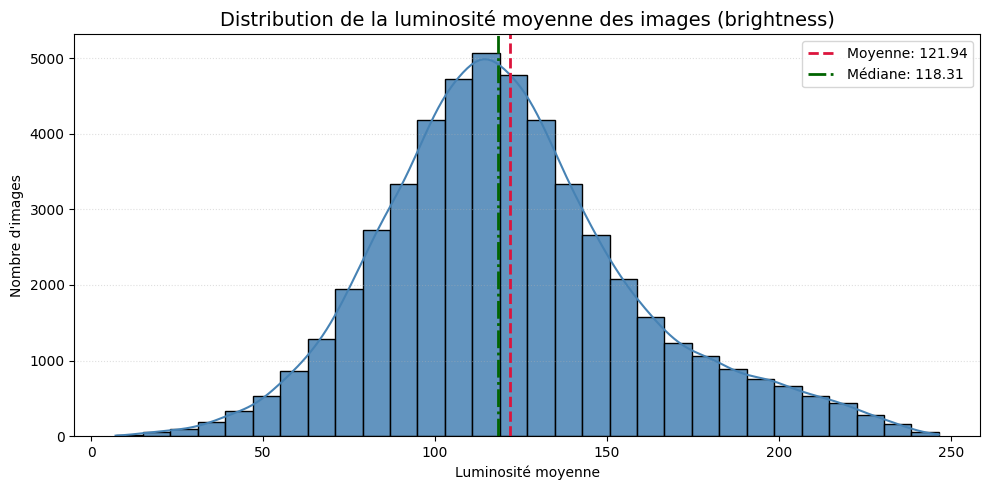

In [44]:
# Statistiques images
# Distribution luminosité
mean_brightness = brightness_scores.mean()
median_brightness = np.median(brightness_scores)

plt.figure(figsize=(10, 5))
sns.histplot(brightness_scores, bins=30, kde=True, color='steelblue', alpha=0.85)
plt.axvline(mean_brightness, color='crimson', linestyle='--', linewidth=2, label=f"Moyenne: {mean_brightness:.2f}")
plt.axvline(median_brightness, color='darkgreen', linestyle='-.', linewidth=2, label=f"Médiane: {median_brightness:.2f}")
plt.title("Distribution de la luminosité moyenne des images (brightness)", fontsize=14)
plt.xlabel("Luminosité moyenne")
plt.ylabel("Nombre d'images")
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

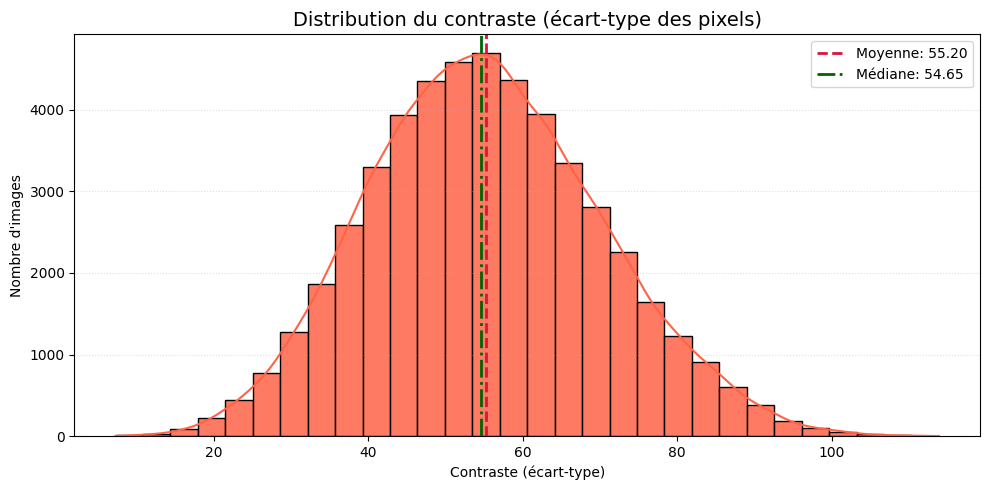

In [45]:
# Distribution contraste
mean_contrast = contrast_scores.mean()
median_contrast = np.median(contrast_scores)
plt.figure(figsize=(10, 5))
sns.histplot(contrast_scores, bins=30, kde=True, color='tomato', alpha=0.85)
plt.axvline(mean_contrast, color='crimson', linestyle='--', linewidth=2, label=f"Moyenne: {mean_contrast:.2f}")
plt.axvline(median_contrast, color='darkgreen', linestyle='-.', linewidth=2, label=f"Médiane: {median_contrast:.2f}")
plt.title("Distribution du contraste (écart-type des pixels)", fontsize=14)
plt.xlabel("Contraste (écart-type)")
plt.ylabel("Nombre d'images")
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

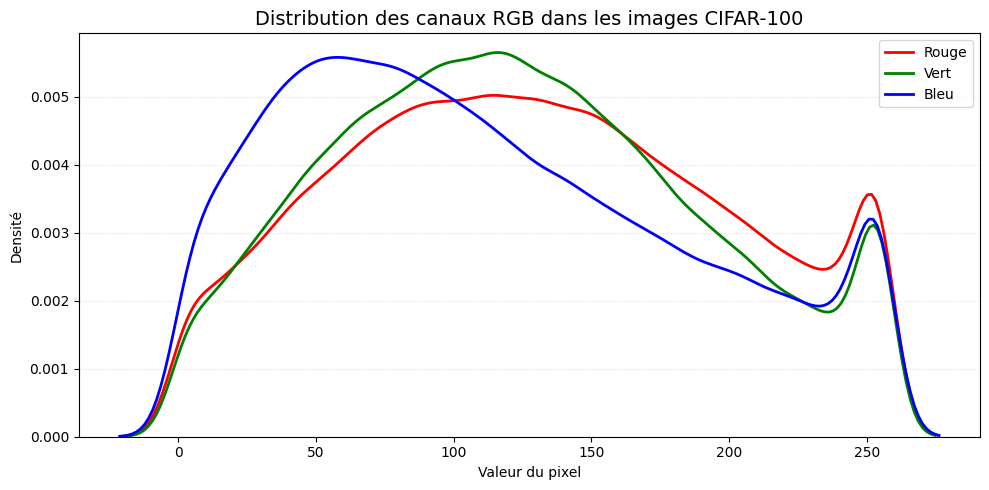

In [46]:
r_values = x_train[:, :, :, 0].ravel()
g_values = x_train[:, :, :, 1].ravel()
b_values = x_train[:, :, :, 2].ravel()

sample_size = 100_000
idx = np.random.choice(len(r_values), sample_size, replace=False)

plt.figure(figsize=(10, 5))
sns.kdeplot(r_values[idx], label='Rouge', color='red', linewidth=2)
sns.kdeplot(g_values[idx], label='Vert', color='green', linewidth=2)
sns.kdeplot(b_values[idx], label='Bleu', color='blue', linewidth=2)
plt.title("Distribution des canaux RGB dans les images CIFAR-100", fontsize=14)
plt.xlabel("Valeur du pixel")
plt.ylabel("Densité")
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


- bleu légèrement dominant
- pic fort vers blanc
- différences légères entre canaux

In [47]:
# Vectorized corruption detection
all_black = (x_train == 0).all(axis=(1, 2, 3))
all_white = (x_train == 255).all(axis=(1, 2, 3))

# If compute_contrast uses std:
contrast = x_train.std(axis=(1, 2, 3))


low_contrast = contrast < 5

corrupted_mask = all_black | all_white | low_contrast
corrupted_indices = np.where(corrupted_mask)[0]

print(f"Nombre d'images potentiellement corrompues ou bizarres: {len(corrupted_indices)}")

if len(corrupted_indices) > 0:
    print("Exemples d'images corrompues ou bizarres:")
    plt.figure(figsize=(12, 4))
    for i, idx in enumerate(corrupted_indices[:10]):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_train[idx])
        plt.axis('off')
        plt.title(f"Index: {idx}\nClasse fine: {fine_labels[y_fine_flat[idx]]}", fontsize=8)
    plt.suptitle("Exemples d'images potentiellement corrompues ou bizarres", fontsize=14)
    plt.tight_layout()
    plt.show()


Nombre d'images potentiellement corrompues ou bizarres: 0


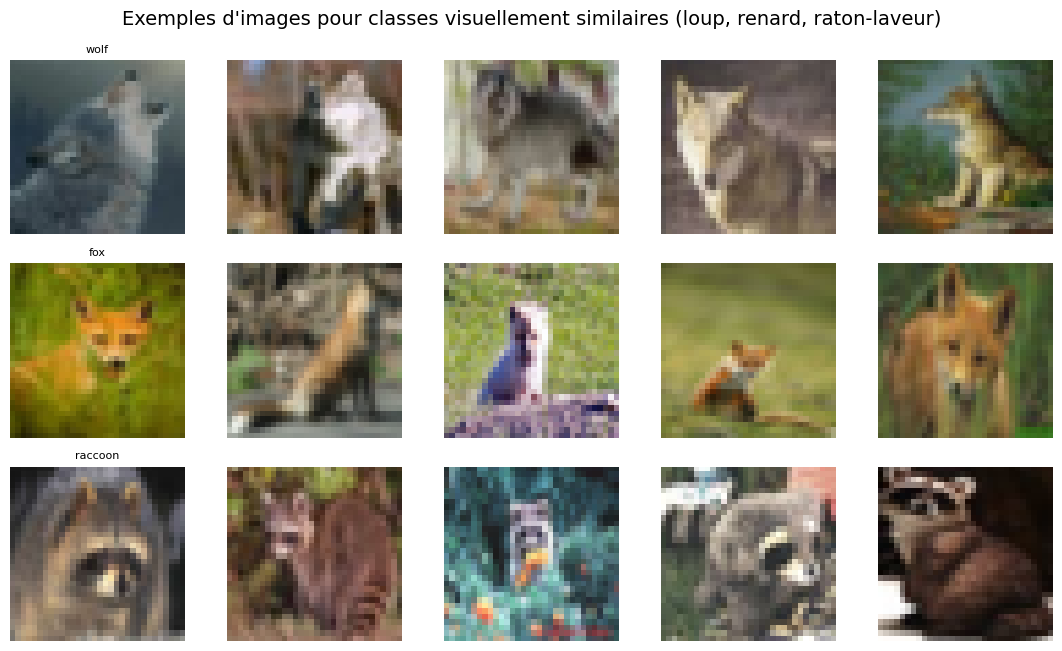

In [48]:
# 4 Analyse classes confondues
# Animaux similaires : loup vs renard vs raton-laveur
similar_classes = [97, 34, 66]  # wolf, fox, raccoon
similar_names = [fine_labels[c] for c in similar_classes]
similar_indices = [np.where(y_fine_flat == c)[0] for c in similar_classes]
n_show = 5
fig, axes = plt.subplots(len(similar_classes), n_show, figsize=(n_show * 2.2, len(similar_classes) * 2.2))
for row, class_id in enumerate(similar_classes):
    idx = similar_indices[row]
    chosen = np.random.choice(idx, n_show, replace=False)
    for col, img_idx in enumerate(chosen):
        ax = axes[row, col]
        ax.imshow(x_train[img_idx])
        ax.axis('off')
        if col == 0:
            ax.set_title(similar_names[row], fontsize=8)
fig.suptitle("Exemples d'images pour classes visuellement similaires (loup, renard, raton-laveur)", fontsize=14)
plt.tight_layout()
plt.show()


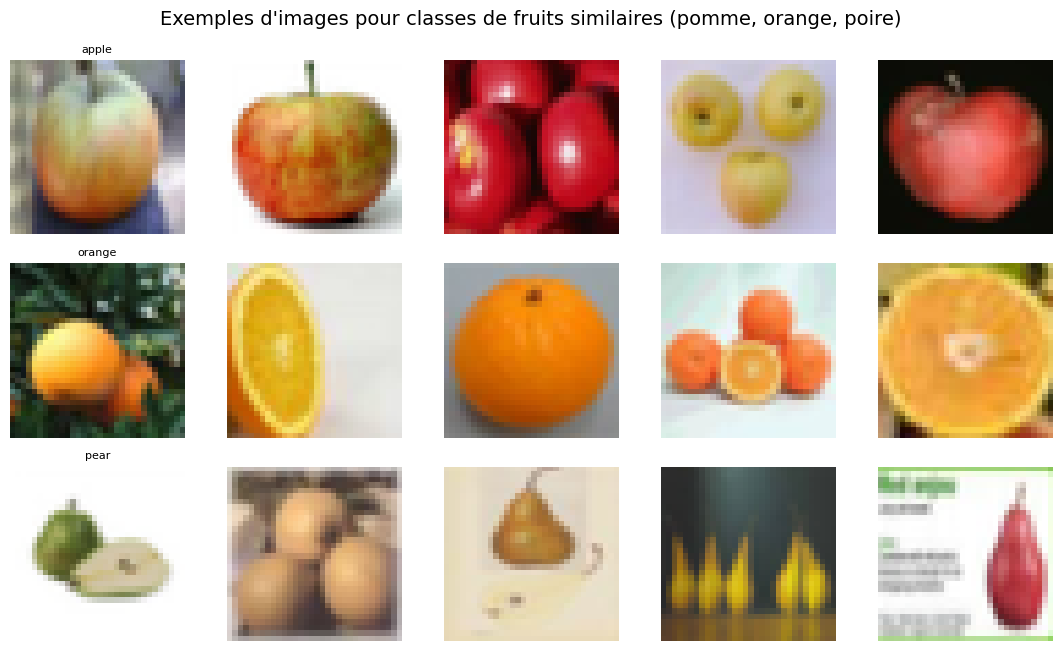

In [49]:
# Fruits : pomme vs orange vs poire
fruit_classes = [0, 53, 57]  # apple, orange, pear
fruit_names = [fine_labels[c] for c in fruit_classes]
fruit_indices = [np.where(y_fine_flat == c)[0] for c in fruit_classes]
fig, axes = plt.subplots(len(fruit_classes), n_show, figsize=(n_show * 2.2, len(fruit_classes) * 2.2))
for row, class_id in enumerate(fruit_classes):
    idx = fruit_indices[row]
    chosen = np.random.choice(idx, n_show, replace=False)
    for col, img_idx in enumerate(chosen):
        ax = axes[row, col]
        ax.imshow(x_train[img_idx])
        ax.axis('off')
        if col == 0:
            ax.set_title(fruit_names[row], fontsize=8)
fig.suptitle("Exemples d'images pour classes de fruits similaires (pomme, orange, poire)", fontsize=14)
plt.tight_layout()
plt.show()


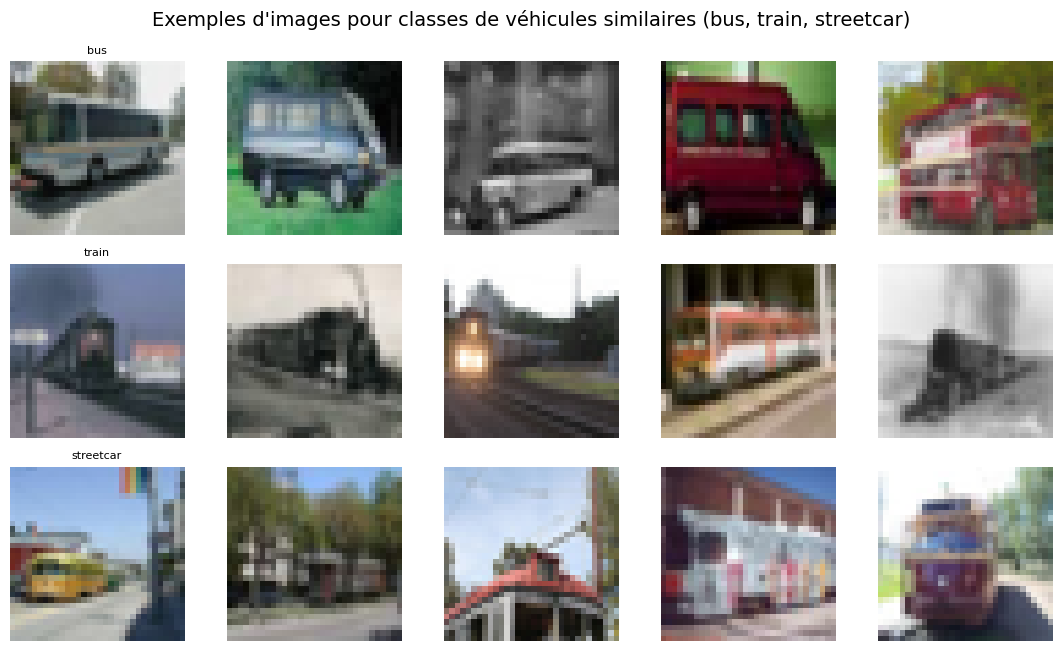

In [50]:
# Véhicules : bus vs train vs streetcar
vehicle_classes = [13, 90, 81]  # bus, train, streetcar
vehicle_names = [fine_labels[c] for c in vehicle_classes]
vehicle_indices = [np.where(y_fine_flat == c)[0] for c in vehicle_classes]
fig, axes = plt.subplots(len(vehicle_classes), n_show, figsize=(n_show * 2.2, len(vehicle_classes) * 2.2))
for row, class_id in enumerate(vehicle_classes):
    idx = vehicle_indices[row]
    chosen = np.random.choice(idx, n_show, replace=False)
    for col, img_idx in enumerate(chosen):
        ax = axes[row, col]
        ax.imshow(x_train[img_idx])
        ax.axis('off')
        if col == 0:
            ax.set_title(vehicle_names[row], fontsize=8)
fig.suptitle("Exemples d'images pour classes de véhicules similaires (bus, train, streetcar)", fontsize=14)
plt.tight_layout()
plt.show()


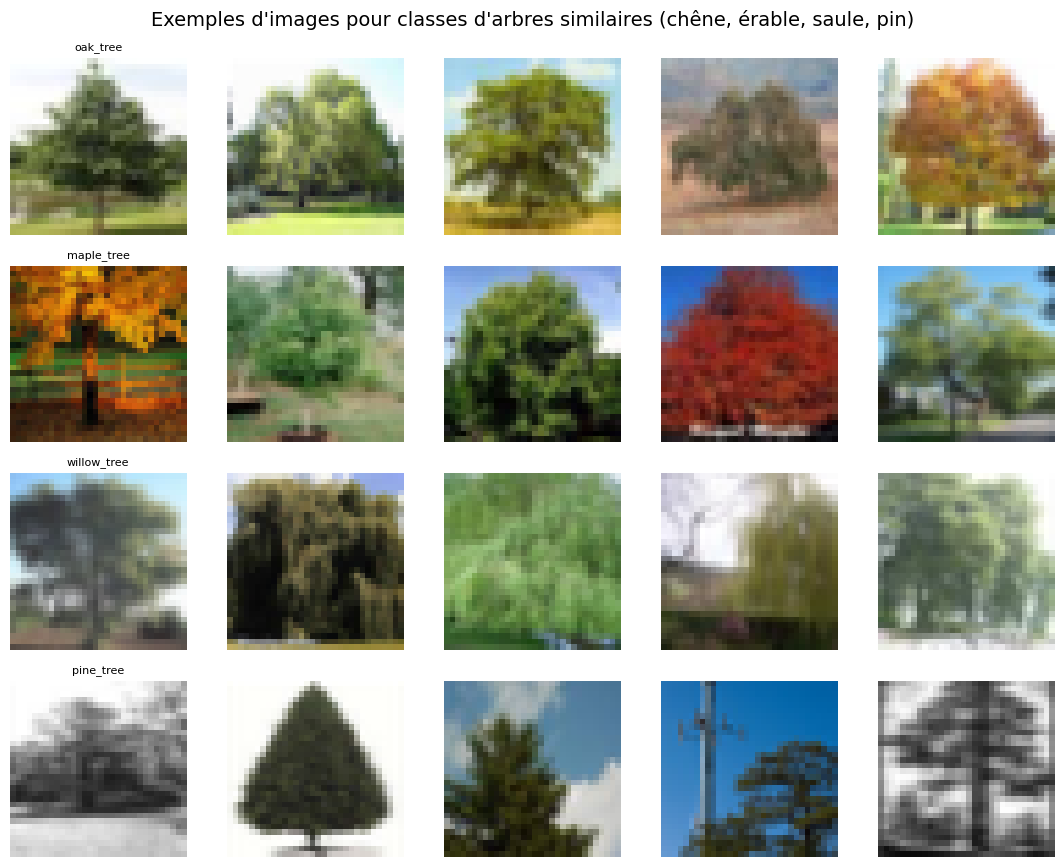

In [51]:
# Arbres : chêne vs érable vs saule vs pin
tree_classes = [52, 47, 96, 59]  # oak_tree, maple_tree, willow_tree, pine_tree
tree_names = [fine_labels[c] for c in tree_classes]
tree_indices = [np.where(y_fine_flat == c)[0] for c in tree_classes]
fig, axes = plt.subplots(len(tree_classes), n_show, figsize=(n_show * 2.2, len(tree_classes) * 2.2))
for row, class_id in enumerate(tree_classes):
    idx = tree_indices[row]
    chosen = np.random.choice(idx, n_show, replace=False)
    for col, img_idx in enumerate(chosen):
        ax = axes[row, col]
        ax.imshow(x_train[img_idx])
        ax.axis('off')
        if col == 0:
            ax.set_title(tree_names[row], fontsize=8)
fig.suptitle("Exemples d'images pour classes d'arbres similaires (chêne, érable, saule, pin)", fontsize=14)
plt.tight_layout()
plt.show()

In [52]:
# 5 Analyse des super-classes
# Distribution des 10 classes dans les 20 super classes
y_coarse_flat = y_train_coarse.flatten()
coarse_counts = Counter(y_coarse_flat)
print("Distribution des super-classes (coarse) dans le train:")
for coarse_id, count in coarse_counts.items():
    print(f"  {coarse_labels[coarse_id]:30s}: {count} images")

Distribution des super-classes (coarse) dans le train:
  large_omnivores_and_herbivores: 2500 images
  reptiles                      : 2500 images
  fruit_and_vegetables          : 2500 images
  people                        : 2500 images
  fish                          : 2500 images
  household_electrical_devices  : 2500 images
  vehicles_1                    : 2500 images
  food_containers               : 2500 images
  large_natural_outdoor_scenes  : 2500 images
  trees                         : 2500 images
  flowers                       : 2500 images
  large_man-made_outdoor_things : 2500 images
  large_carnivores              : 2500 images
  small_mammals                 : 2500 images
  household_furniture           : 2500 images
  medium_mammals                : 2500 images
  vehicles_2                    : 2500 images
  insects                       : 2500 images
  non-insect_invertebrates      : 2500 images
  aquatic_mammals               : 2500 images


In [53]:
# Classe les plus difficile par super classe
print("\nClasse la plus difficile par super-classe (coarse) :")
for coarse_id, fine_ids in coarse_to_fine.items():
    fine_counts = [Counter(y_fine_flat)[fid] for fid in fine_ids]
    hardest_fine_id = fine_ids[np.argmin(fine_counts)]
    print(f"  {coarse_labels[coarse_id]:30s} -> {fine_labels[hardest_fine_id]:20s} ({fine_counts[np.argmin(fine_counts)]} images)")


Classe la plus difficile par super-classe (coarse) :
  aquatic_mammals                -> beaver               (500 images)
  fish                           -> aquarium_fish        (500 images)
  flowers                        -> orchid               (500 images)
  food_containers                -> bottle               (500 images)
  fruit_and_vegetables           -> apple                (500 images)
  household_electrical_devices   -> clock                (500 images)
  household_furniture            -> bed                  (500 images)
  insects                        -> bee                  (500 images)
  large_carnivores               -> bear                 (500 images)
  large_man-made_outdoor_things  -> bridge               (500 images)
  large_natural_outdoor_scenes   -> cloud                (500 images)
  large_omnivores_and_herbivores -> camel                (500 images)
  medium_mammals                 -> fox                  (500 images)
  non-insect_invertebrates       -> 

## 6. Planification stratégie pour la Phase 2

### Conclusions de l'exploration

| Observation | Impact |
|---|---|
| 500 images/classe (train), 100 (test) | Peu de données → augmentation **obligatoire** |
| Images 32×32 pixels | Résolution très faible → upscale pour transfer learning |
| Pixels en uint8, range [0, 255] | Normalisation nécessaire avant entraînement |
| 0 image corrompue | Pas de nettoyage à faire |
| Classes parfaitement équilibrées (500 exactement) | Pas besoin de class weighting |
| Forte confusion intra-super-classe (loup/renard, arbres...) | La hiérarchie coarse peut aider |

---

### Décisions stratégiques

#### 1. Normalisation
- **CNN personnalisé** → normalisation simple : `X / 255.0`
- **Transfer learning (MobileNetV2, EfficientNet)** → normalisation ImageNet :
  - mean = [0.485, 0.456, 0.406] / std = [0.229, 0.224, 0.225]

#### 2. Taille cible des images
- **CNN simple** → garder 32×32 (pas de redimensionnement)
- **Transfer learning** → upscale vers **96×96** (compromis vitesse/qualité) ou 224×224

#### 3. Data augmentation (CRITIQUE)
Avec seulement 500 images/classe, l'augmentation est indispensable :
- Flip horizontal ✓
- Rotation ±20° ✓
- Zoom ±25% ✓
- Shift horizontal/vertical ±15% ✓
- Variation de luminosité ±20% ✓
- Cutout / Random Erasing (recommandé)

#### 4. Encodage des labels
- Labels fine → one-hot sur 100 classes
- Labels coarse → one-hot sur 20 super-classes (pour modèle hiérarchique optionnel)

#### 5. Transfer learning obligatoire
600 images/classe est insuffisant pour entraîner un CNN from scratch performant.  
→ MobileNetV2 et EfficientNetB0 pré-entraînés sur ImageNet sont **obligatoires** pour atteindre >50% accuracy.